# Project Motivation

**Task** - the task is a to approximate a smooth non-linear function on a bounded 2D domain

Essentially this is a supervised regression task

As this project is for learning purposes rather pure practicality, we will be using a neural network even though there are more efficient methods of function interpolation.

### Why, can we use a neural network?
-- NEED TO ADD THAT WE CAN DO THIS USING UAT


Before we look at model architecture, training and so on, let's take a look at the data.

## Data Generation

For this project we will create synthetic data.
Here is the methodology :

We have some known smooth and non-linear function $f : [a,b]^2 \to \mathbb{R} , f(x,y)$   
where $a,b\in\mathbb{R}$

To generate the dataset, we take $n$ points $(x,y)\in[a,b]^2$
Then, we evaluate the function at these points and add some noise  
This gives us : $z_{i} = f(x_{i},y_{i}) + \epsilon_{i}\;\;1\leq i\leq n$ where $\epsilon_{i}\sim N(0,\sigma^2)\;\;i.d.d$  
This gives us the final dataset $\mathbf{D}=\{(x_{i} , y_{i} , z_{i}) \}_{i=1}^n$

This is implemented in the code below

So now we have our dataset $\mathbf{D}$, we can begin to think about the model and its implementation.

We need to : 

1) Choose a model
2) Choose a loss function
3) Choose weights that makes F a close approximation of the target function

#### (1) Choosing a model
We have already decided to use a neural network but we need to think about its structure.
For now, we will consider a simple Feed-Forward Network.

##### Feed-Forward Neural Network
<img src="fnn_diagram.png" alt="Feed-Forward Neural Network Diagram"/>

I have drawn this graph to show the general structure of an FNN.

An FNN simply consists of a set of "neurons" or "nodes" (taking inspiration from neurons in the brain).

These are modelled to be basic units of computation.
Typically, each neuron performs a weighted sum on its inputs and then adds some bias. To allow a network to capture more complex patterns, we then introduce non-linearity by applying a post activation function, giving a final output.
  
We then group a some of these neurons together, forming what we call a "layer".  
Thinking about a network in terms of its layers makes it easier when it comes to implementation.

We then take some these layers to form the network as shown above.  
The input layer just refers to the information we input into the network and does not actually perform any computation.  
The intermediate layers are called "hidden" because a user cannot directly interact with them. They perform most/all of the computation.  
Finally, we have the output layer which again doesn't perform any computation and is just the output of the network.  

How is everything connected?
Generally in an FNN, each neuron passes its output to every node in the next layer. This means that the network is "fully" connected.  
  
In different models, layers might not be sequentially arranged, the network might not be fully connected, and other modifications may be added. Additionally, we can make adjustments to model's architecture to improve the model's performance. 

How do we implement this/represent this mathematically?
  
*for convenience, i will explain everything in real numbers, but we can use different objects and so forth.*  
Representing a neuron:   
Suppose, we have $n$ inputs with the $i^{th}$ input, $x_i\in\mathbb{R}$ having weight $w_i\in\mathbb{R}$.  
We can then represent the weighted sum as $$\sum_{i=1}^{n}w_i x_i$$  
We can then add a bias term $b\in\mathbb{R}$, and then apply some activation function $\sigma:\mathbb{R}\to\mathbb{R}$
This gives us the output of a neuron $y\in\mathbb{R}$ as $$y=\sigma\big(\sum_{i=1}^n w_i x_i + b\big)$$


This is for one neuron, but what if we want to represent many neurons at once?  It would be quite messy to store and manage each neuron individually so we use linear algebra to help represent everything neatly.  
Notice that we can write the weighted sum for the $j^{th}$ node (with the $i^{th}$ input having a weight $w_ji$ for the $j^{th} node$) as $$\sum_{i=1}^n w_jix_i$$

This is actually the $i,j$ entry of some matrix multiplication $A\underline{x}$ where $A\in\mathbb{R}^{m \times n}$ and $\underline{x}\in\mathbb{R}^n$
# COMPLETE EXPLANATION

In [36]:
#Libraries needed

import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

In [ ]:
rand = np.random.default_rng(42)


a = -100
b = 100
n = 1000

#Our target function f
def f(x,y):
    return x**2+y**2

def g(x,y):
    return np.sqrt(abs(1-x**2-y**2))

def h(x,y):
    return 1/(1+25*x**2)

def i(x,y):
    return np.sin(1/x)


xcoords = rand.uniform(low=a,high=b,size=(n,1))
ycoords = rand.uniform(low=a,high=b,size=(n,1))

zcoords = g(xcoords,ycoords)

dataset = np.concatenate((xcoords,ycoords,zcoords),axis=1)

#formatting coords for input
TestTrainSplit = 0.8
batches = 5
SplitIndex = int(TestTrainSplit*n)
TrainData  = dataset[:SplitIndex]
TestData = dataset[SplitIndex:]

noise = rand.normal(loc=0,scale=1,size=(SplitIndex,1))
TrainData[:,-1] = (TrainData[:,-1].reshape(SplitIndex,1) + noise).reshape(SplitIndex)


#scaling the dataset
mean = np.mean(TrainData,0)
SD = np.std(TrainData,0)

ScaledTrainData = (TrainData - mean)/SD

TrainDataBatches = np.split(TrainData,batches)

#Simple scatter plot for visualisation
fig = px.scatter_3d(TrainData,x=0,y=1,z=2)
fig.show()

In [38]:
def ReLu(x):
    return np.maximum(0,x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def swish(x):
    return x * sigmoid(x)
def MSE(labels,predictions):
    loss = np.sum((predictions - labels)**2)
    loss = loss/predictions.shape[0]
    return loss

def RMSE(labels,predictions):
    loss = MSE(labels,predictions)
    return np.sqrt(loss)


def MinMax(x,min,max):
    return (x-min)/(max-min)

def InvMinMax(x,min,max):
    return  x * (max-min) + min

def normalise(x,mean,var,epsilon=1e-5):
    return (x-mean)/np.sqrt(var+epsilon)

def InvNormalise(x,mean,var,epsilon=1e-5):
    return x * np.sqrt(var + epsilon) + mean

In [39]:
#LayerWidths -> an arr storing the number of neurons in the (k+1)th layer (left to right)
#PostActFuncs -> an arr storing the post-act func of each layer
class network:
    def __init__(self, LayerWidths,PostActivationFuncs):
        self.LayerNum = len(LayerWidths)-1
        self.LayerWidths = LayerWidths
        self.PostActivationFuncs = PostActivationFuncs
        self.layers = []
        self.LayerOutputs = []
        for i in range(1,self.LayerNum+1):
            layeri= layer(LayerWidths[i-1],LayerWidths[i],PostActivationFuncs[i])
            self.layers.append(layeri)


    def ForwardPass(self,input):
        self.LayerOutputs.clear()
        for i in range(self.LayerNum):
           input , LayerComputations = self.layers[i].compute(input)
           self.LayerOutputs.append(LayerComputations)

        return input

class layer:
    def __init__(self,InputWidth,width,PostActFunc):
        sigma = np.sqrt(2/(InputWidth+width))
        self.width = width
        self.PostActFunc = PostActFunc
        self.InputWidth = InputWidth
        self.weights = np.array(rand.normal(0,sigma, size=(width,InputWidth)))
        self.bias = np.array(rand.normal(0,sigma, size=(width,1)))
        #stochatistcally initialise a matrix


    def compute(self,input):
        computations = {}
        LinearComputation = self.weights@input + self.bias
        computations["Linear"] = LinearComputation


        PostActComputation = self.PostActFunc(LinearComputation)
        computations["LayerOutput"] = PostActComputation
        return PostActComputation , computations

In [40]:
#formed the netowrk
fnn = network([2,32,32,32,1],[lambda x : x,np.tanh,np.tanh,np.tanh,lambda x : x])

In [41]:
def GradDesc(CurrVal,Gradient,LearningRate=0.001):
    return CurrVal - LearningRate*Gradient

In [42]:
BatchLossVals = [[] for i in range(batches)]
TotalLossVals = []
epochs = int(2000)
LearningRate = 1e-1
RegParam = 0.0
loss = 0
InputShape = (2,1)


for epoch in range(epochs):
    indexes = np.arange(0,len(TrainDataBatches)-1)
    np.random.shuffle(indexes)

    for index in indexes:
        CurrentBatch = TrainDataBatches[index]
        N = CurrentBatch.shape[0]

        W4 = fnn.layers[3].weights
        b4 = fnn.layers[3].bias

        W3 = fnn.layers[2].weights
        b3 = fnn.layers[2].bias

        W2 = fnn.layers[1].weights
        b2 = fnn.layers[1].bias

        W1 = fnn.layers[0].weights
        b1 = fnn.layers[0].bias

        dW4 = np.zeros((W4.shape))
        db4 = np.zeros((b4.shape))

        dW3 = np.zeros((W3.shape))
        db3 = np.zeros((b3.shape))

        dW2 = np.zeros((W2.shape))
        db2 = np.zeros((b2.shape))

        dW1 = np.zeros((W1.shape))
        db1 = np.zeros((b1.shape))

        predictions = np.zeros((N,1))
        labels = np.zeros((N,1))

        for i in range(N):
            x = CurrentBatch[i,:-1].reshape(InputShape)
            label = CurrentBatch[i,-1]
            prediction = fnn.ForwardPass(x)

            predictions[i] = prediction
            labels[i] = label

            #layer 4
            a3_i = fnn.LayerOutputs[2]["LayerOutput"]

            dLdy_i = 2/N * (prediction - label)
            db4 += dLdy_i
            dW4 += dLdy_i * a3_i.T

            #layer 3
            a2_i = fnn.LayerOutputs[1]["LayerOutput"]

            delta3 = (W4.T * dLdy_i) * (1 - a3_i ** 2)

            dW3 += delta3 @ a2_i.T
            db3 += delta3

            #Layer 2
            a1_i = fnn.LayerOutputs[0]["LayerOutput"]

            delta2 = (W3.T @ delta3) * (1-a2_i**2)

            dW2 += delta2 @ a1_i.T
            db2 += delta2

            #Layer 1
            delta1 = (W2.T @ delta2) * (1-a1_i**2)

            dW1 += delta1 @ x.T
            db1 += delta1



        fnn.layers[3].bias = GradDesc(b4,1/N * db4,LearningRate)
        fnn.layers[3].weights = GradDesc(W4,1/N * dW4,LearningRate)

        fnn.layers[2].bias = GradDesc(b3,1/N * db3,LearningRate)
        fnn.layers[2].weights = GradDesc(W3,1/N * dW3,LearningRate)

        fnn.layers[1].bias = GradDesc(b2,1/N * db2,LearningRate)
        fnn.layers[1].weights = GradDesc(W2,1/N * dW2,LearningRate)

        fnn.layers[0].bias = GradDesc(b1,1/N * db1,LearningRate)
        fnn.layers[0].weights = GradDesc(W1,1/N * dW1,LearningRate)


        loss =  MSE(labels,predictions)
        BatchLossVals[index].append(loss)
        TotalLossVals.append(loss)

    print(f"epoch: {epoch}, loss: {loss}")













epoch: 0, loss: 4338.444819897868
epoch: 1, loss: 2289.174113254836
epoch: 2, loss: 1897.9132503202295
epoch: 3, loss: 1353.2907423334696
epoch: 4, loss: 1094.410690315764
epoch: 5, loss: 989.1934073807422
epoch: 6, loss: 1020.7028671038012
epoch: 7, loss: 934.4228247011382
epoch: 8, loss: 833.32905909197
epoch: 9, loss: 952.2213718773795
epoch: 10, loss: 755.2970813272987
epoch: 11, loss: 807.6879487178148
epoch: 12, loss: 828.6554545049241
epoch: 13, loss: 764.5114077694537
epoch: 14, loss: 998.8104616959606
epoch: 15, loss: 801.2219179045178
epoch: 16, loss: 719.1605343329857
epoch: 17, loss: 744.9943606722056
epoch: 18, loss: 951.1791986403769
epoch: 19, loss: 764.3079374223589
epoch: 20, loss: 698.4323307790576
epoch: 21, loss: 778.0650598630187
epoch: 22, loss: 689.4433604621308
epoch: 23, loss: 784.2554771893676
epoch: 24, loss: 787.5082239801807
epoch: 25, loss: 749.8671227334402
epoch: 26, loss: 635.4239821835785
epoch: 27, loss: 701.8130408840901
epoch: 28, loss: 634.44734534

In [43]:
for layer in fnn.layers:
    print(f"weight : {layer.weights}")

weight : [[ 1.08303128  2.22484713]
 [-0.69093413 -1.31373851]
 [-1.31287066  0.3084053 ]
 [-0.72988548 -0.79133814]
 [-2.11012621  0.6995429 ]
 [ 1.09308502  0.73546777]
 [-1.23744347 -0.90070772]
 [-0.75638074 -0.89606916]
 [-0.61940968 -0.64423367]
 [ 0.66058536  0.53615378]
 [-0.59106988 -0.78460937]
 [ 1.18414187  0.75249896]
 [ 1.70877424  1.34117742]
 [-1.23160184 -1.77755306]
 [-1.93159753  0.63869469]
 [-0.67083705 -0.59679749]
 [-1.07721288 -0.8677549 ]
 [-1.35625479 -1.80057936]
 [-1.1029223  -3.20958804]
 [-0.74658166 -0.75545672]
 [-1.01761417  0.04020148]
 [ 1.90987592  1.13512529]
 [-2.72485902 -2.22547391]
 [ 1.60368616  1.19719645]
 [ 0.70937737  0.85948452]
 [-1.00596108 -1.1017495 ]
 [-0.87348408 -0.69322061]
 [-0.97171815 -0.97007352]
 [ 0.7926278   0.80118394]
 [-0.71965557 -0.50535522]
 [ 0.90630191  0.98635041]
 [-0.64472356 -0.56458666]]
weight : [[ 0.08167483  0.39237269 -0.04893448 ... -0.16662331 -0.33938689
  -0.08987116]
 [-0.27627437  0.01545573 -0.4748853

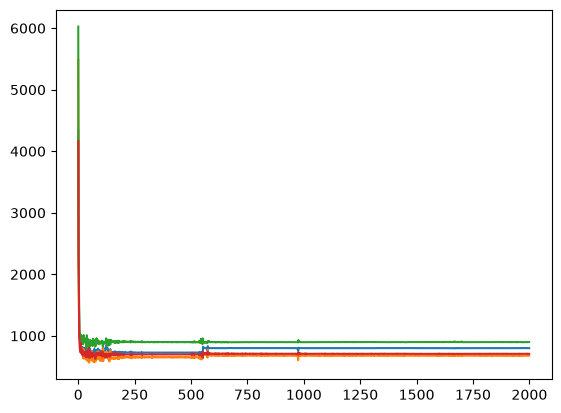

In [44]:
for j in range(len(BatchLossVals)):
    plt.plot([i for i in range(len(BatchLossVals[j]))],BatchLossVals[j])
plt.show()

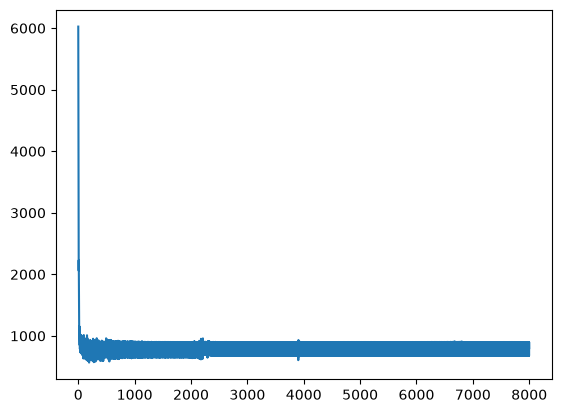

In [45]:
plt.plot(np.arange(0,len(TotalLossVals)),TotalLossVals)
plt.show()

In [46]:
TestPredictions = np.zeros((TestData.shape[0],1))

for i in range(TestData.shape[0]):
    x = TestData[i,:-1].reshape(InputShape)
    TestPrediction = fnn.ForwardPass(x)
    TestPredictions[i] = TestPrediction
    print(f"prediction : {TestPrediction[0][0]}, actual value : {TestData[i,-1]}")


TestLabels = TestData[:,-1].reshape(TestData.shape[0],1)
TestLoss = RMSE(TestLabels,TestPredictions)

print(f"RMSE on test is {TestLoss}")

prediction : 75.21368310277396, actual value : 47.562507840059524
prediction : 75.21368310277396, actual value : 92.8917606038523
prediction : 75.21368310277396, actual value : 76.10223469975573
prediction : 64.59506989159566, actual value : 43.0069227835059
prediction : 75.21368310277396, actual value : 138.05503322938264
prediction : 75.21368310277396, actual value : 106.46305925061553
prediction : 75.21368310277184, actual value : 49.29978774822036
prediction : 75.21368310277396, actual value : 82.08138197864822
prediction : 64.58407783254955, actual value : 17.82168569554521
prediction : 75.21368310277396, actual value : 102.38261778211364
prediction : 75.21368310277396, actual value : 97.42412192376591
prediction : 75.21368310277396, actual value : 106.08723741490462
prediction : 64.62292050339241, actual value : 89.17501199837571
prediction : 75.21368310277396, actual value : 132.3835758984133
prediction : 64.62292378874086, actual value : 98.29143488811764
prediction : 64.587807

In [47]:
## Linear regression

import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_squared_error

X_train = TrainData[:,:-1]
y_train = TrainData[:,-1]
X_test = TestData[:,:-1]
y_test = TestData[:,-1]
# baselines
poly = LinearRegression().fit(PolynomialFeatures(2).fit_transform(X_train), y_train)
gp = GaussianProcessRegressor(kernel=RBF(length_scale=0.5)).fit(X_train, y_train)

print("Poly MSE:", mean_squared_error(y_test, poly.predict(PolynomialFeatures(2).fit_transform(X_test))))
print("GP MSE:  ", mean_squared_error(y_test, gp.predict(X_test)))
# then compare your NN's MSE to these

Poly MSE: 5.758625555448789
GP MSE:   170.68665398845363


In [ ]:
import torch
from torch import nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.stack = nn.Sequential(
            nn.Linear(2,32),
            nn.Tanh(),
            nn.Linear(32,32),
            nn.Tanh(),
            nn.Linear(32,32),
            nn.Tanh(),
            nn.Linear(32,1),
        )

    def forward(self,x):
        x = self.flatten(x)
        return self.stack(x)




In [ ]:
model = NeuralNetwork()
print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (stack): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
